<h1>Simple Linear Regression</h1>

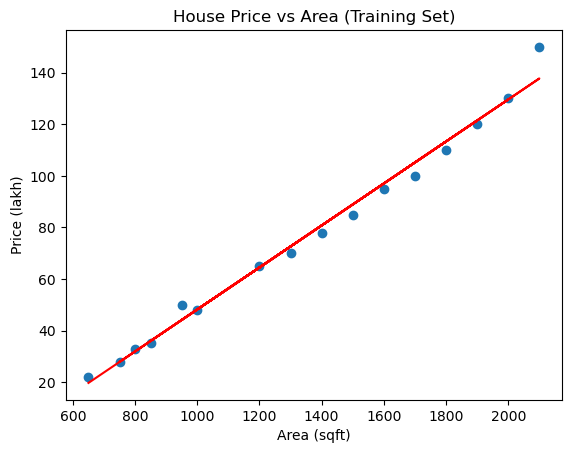

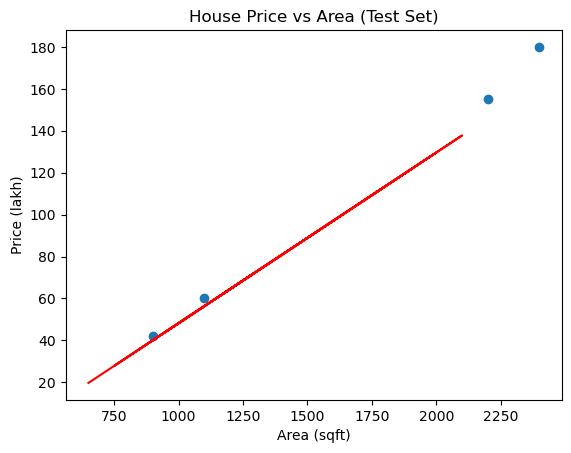

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("house_prices.csv")

X = df[['area_sqft']].values
y = df['price_lakh'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

model = LinearRegression()
model.fit(X_train, y_train)

# Training set
plt.figure()
plt.scatter(X_train, y_train)
plt.plot(X_train, model.predict(X_train), color="red")

plt.title("House Price vs Area (Training Set)")
plt.xlabel("Area (sqft)")
plt.ylabel("Price (lakh)")

plt.show()


# Test set
plt.figure()
plt.scatter(X_test, y_test)
plt.plot(X_train, model.predict(X_train), color="red")

plt.title("House Price vs Area (Test Set)")
plt.xlabel("Area (sqft)")
plt.ylabel("Price (lakh)")

plt.show()

Predicted Price: 109.26764436296975 lakh
Area: 1200 sqft → Predicted Price: 64.48 lakh
Area: 1600 sqft → Predicted Price: 97.05 lakh
Area: 2000 sqft → Predicted Price: 129.62 lakh


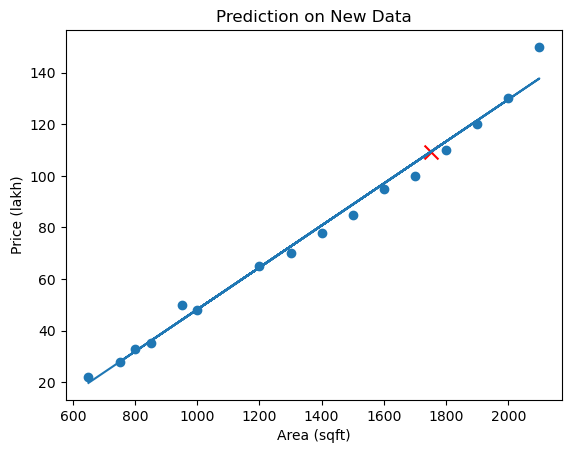

In [5]:
# Predictions

new_area = np.array([[1750]])
predicted_price = model.predict(new_area)
print("Predicted Price:", predicted_price[0], "lakh")

new_areas = np.array([[1200], [1600], [2000]])
predictions = model.predict(new_areas)

for area, price in zip(new_areas, predictions):
    print(f"Area: {area[0]} sqft → Predicted Price: {price:.2f} lakh")

plt.figure()
plt.scatter(X_train, y_train)

plt.plot(X_train, model.predict(X_train))

plt.scatter(1750, predicted_price, marker='x', s=100, color="red")

plt.title("Prediction on New Data")
plt.xlabel("Area (sqft)")
plt.ylabel("Price (lakh)")

plt.show()

<h1>Multiple Linear Regression</h1>

In [6]:
df = pd.read_csv("student_scores.csv")

df

,hours_studied,attendance,previous_score,study_method,final_score
0,2,60,50,Self,55
1,3,65,55,Self,60
2,4,70,60,Coaching,68
3,5,75,65,Coaching,75
4,6,80,70,Online,78
5,7,85,72,Online,82
6,8,90,75,Coaching,88
7,1,50,40,Self,45
8,2,55,45,Self,50
9,3,60,50,Online,58


In [7]:
df = pd.get_dummies(df, columns=['study_method'], drop_first=True)

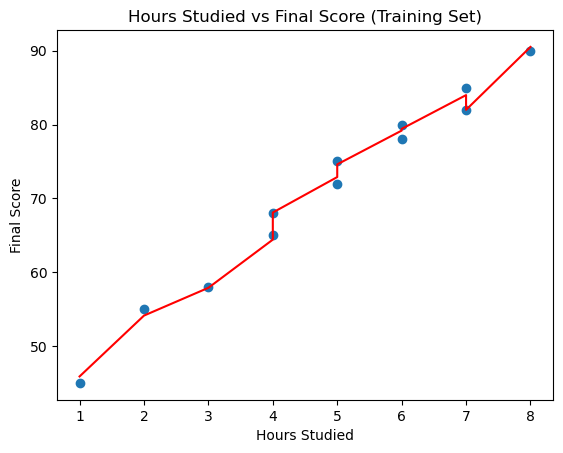

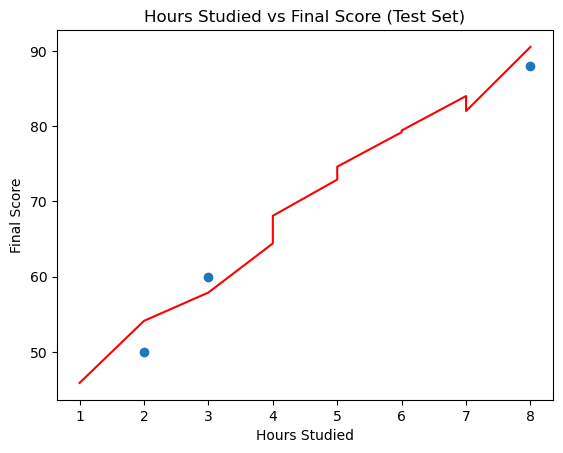

In [8]:

X = df.drop('final_score', axis=1)
y = df['final_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

model = LinearRegression()
model.fit(X_train, y_train)

# Train Set
plt.figure()

plt.scatter(X_train['hours_studied'], y_train)
sorted_index = X_train['hours_studied'].argsort()
X_train_sorted = X_train.iloc[sorted_index]

y_pred_line = model.predict(X_train_sorted)

plt.plot(X_train_sorted['hours_studied'], y_pred_line, color="red")

# Predict using ALL features
y_pred_line = model.predict(X_train_sorted)
plt.title("Hours Studied vs Final Score (Training Set)")
plt.xlabel("Hours Studied")
plt.ylabel("Final Score")

plt.show()

# Test set
plt.figure()

plt.scatter(X_test['hours_studied'], y_test)
plt.plot(X_train_sorted['hours_studied'], y_pred_line, color="red")

plt.title("Hours Studied vs Final Score (Test Set)")
plt.xlabel("Hours Studied")
plt.ylabel("Final Score")

plt.show()

In [9]:
df

,hours_studied,attendance,previous_score,final_score,study_method_Online,study_method_Self
0,2,60,50,55,False,True
1,3,65,55,60,False,True
2,4,70,60,68,False,False
3,5,75,65,75,False,False
4,6,80,70,78,True,False
5,7,85,72,82,True,False
6,8,90,75,88,False,False
7,1,50,40,45,False,True
8,2,55,45,50,False,True
9,3,60,50,58,True,False


In [10]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# R² Score
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)


Model Performance:
MSE: 2.066767701872115
RMSE: 1.4376257168930011
R² Score: 0.9920099186783294
